In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vgg/keras/default/1/vgg_model.h5
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-20-_jpg.rf.bf2a3a5eb89acb02de58bccd79a5515d.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-106-_jpg.rf.fcaa85ea3b822953e2102ef3384532ca.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-179-_jpg.rf.68dd8ede9901c18aae3126f54d145f67.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-194-_jpg.rf.8b53e2b52af411b816676dba1dfcb506.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-77-_jpg.rf.b23fe7ede31f873c273d25a39e8f353b.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-188-_jpg.rf.6bb797d7fe59491a218703437a9c3cbb.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-62-_jpg.rf.1cc00a591d6942f1dedd901c136a335f.jpg
/kaggle/input/dataset-vgg/dataset_vgg/test/Healthy_apricot/GOOD-4-91-_jpg.rf.3e007170e11f413d1676978c95ba9ac3.jpg
/kaggle/input/dataset-vgg/dataset_vgg

In [2]:
pip install tensorflow numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Define image size and batch size
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
# Create data generators
train_datagen = ImageDataGenerator(
rescale=1.0/255,
rotation_range=20,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,
fill_mode='nearest'
)
validation_datagen = ImageDataGenerator(rescale=1.0/255)
train_generator = train_datagen.flow_from_directory(
'/kaggle/input/dataset-vgg/dataset_vgg/train',
target_size=IMAGE_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical'
)
validation_generator = validation_datagen.flow_from_directory(
'/kaggle/input/dataset-vgg/dataset_vgg/test',
target_size=IMAGE_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical'
)

Found 2496 images belonging to 3 classes.
Found 624 images belonging to 3 classes.


In [4]:
cd /kaggle/working/

/kaggle/working


In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load the VGG16 model without the top classification layer
base_model = VGG16(include_top=False, input_shape=(*IMAGE_SIZE, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Define callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint('/kaggle/working/vgg_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
# Train the model
history = model.fit(
train_generator,
epochs=30,
validation_data=validation_generator,
callbacks=[checkpoint, early_stopping]
)


Epoch 1/30


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1724962075.382882      88 service.cc:145] XLA service 0x7b3818013eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1724962075.382940      88 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1724962075.382944      88 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/78 ━━━━━━━━━━━━━━━━━━━━ 29:15 23s/step - accuracy: 0.2500 - loss: 1.7346

I0000 00:00:1724962090.643618      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.5287 - loss: 1.0615
Epoch 1: val_loss improved from inf to 0.87739, saving model to /kaggle/working/vgg_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 80s 741ms/step - accuracy: 0.5300 - loss: 1.0584 - val_accuracy: 0.6026 - val_loss: 0.8774
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7729 - loss: 0.5466
Epoch 2: val_loss improved from 0.87739 to 0.82592, saving model to /kaggle/working/vgg_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 473ms/step - accuracy: 0.7729 - loss: 0.5465 - val_accuracy: 0.6571 - val_loss: 0.8259
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7906 - loss: 0.4918
Epoch 3: val_loss improved from 0.82592 to 0.76442, saving model to /kaggle/working/vgg_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 465ms/step - accuracy: 0.7905 - loss: 0.4918 - val_accuracy: 0.6747 - val_loss: 0.7644
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8044 - loss: 0.4759
Epoch 4: val_loss

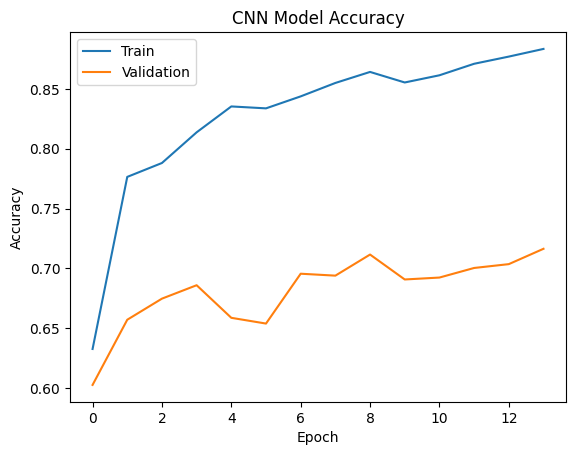

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


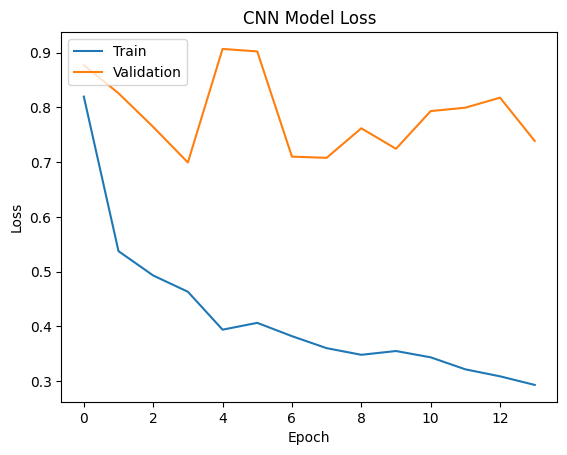

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
